<a href="https://colab.research.google.com/github/asternoeld/avcad/blob/main/exercise1_wordcloud/exercise1_wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Agro-Environmental Data
---
## Exercise 01 — Create your personal word cloud

**Name:** Aster Noel Dsouza  
**Student number:** 29211

This notebook builds a personal word cloud from the keywords in my CV and cover letter
(skills and interests), following the Lesson 1 exercise. It runs top-to-bottom in Google Colab.

### 1. Install and import packages
`wordcloud` is not pre-installed in Colab, so we install it first.

In [1]:
!pip -q install wordcloud
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

### 2. Load my text
The text below is a punctuation-free list of words from my CV and cover letter (skills + interests).
It is embedded here so the notebook is self-contained; the same text is also in `aster_keywords.txt`,
which you can load instead with `open("aster_keywords.txt").read()`.

In [2]:
text = "Business development and project management professional with an engineering background and strong analytical capability Experienced in client partnerships outsourced IT and marketing delivery and data driven decision support Skilled at translating technical and operational complexity into clear actionable outcomes for stakeholders Languages English Hindi Kannada Konkani Portuguese Beginner PERSONAL INTERESTS Digital art and Graphic Design Mural painting Science projects builds DIY builds Aster Noel Dsouza Alc\u00e2ntara Lisbon Dear Hiring Manager I am writing to express my interest in opportunities where I can contribute my experience in business development project management and analytical decision support to help teams deliver measurable outcomes My background combines client facing partnership building commercial execution and structured project delivery across technical and service environments In recent years I have worked through my own consulting practice Utileme supporting organizations with business development outsourced project coordination and operational execution This has involved leading client outreach managing engagement pipelines and collaborating with external teams to deliver IT and marketing initiatives Previously I worked in operational project management at WhiteHat Jr where I supported strategy reporting through data synthesis implemented new workflows and organizational trackers and contributed to establishing contact center outsourcing operations across international markets This experience strengthened my ability to manage complex execution improve processes and maintain high service quality in fast paced environments I also bring hands on experience in customer facing sales and operational support from IKEA where I worked with internal systems to ensure stock accuracy optimize goods flow and enhance the customer journey through proactive engagement Earlier in my career I managed turnkey industrial engineering projects involving technical assessment procurement coordination installation commissioning and long term client support Alongside my professional experience I have developed strong analytical skills through advanced training in Python SQL and evidence based methodology This blend of consulting driven execution operational discipline and structured analysis allows me to adapt across industries and contribute effectively to both growth focused and delivery focused roles I am motivated by opportunities that value clear communication accountability cross functional collaboration and consistent execution I would welcome the opportunity to contribute my skills and experience to your organization s continued success Thank you for your time and consideration I look forward to the possibility of discussing how my background aligns with your needs Business Development Project Management Data Analysis Python SQL Machine Learning Consulting Client Partnerships Marketing Engineering Operations Stakeholders Decision Support Digital Art Graphic Design Mural Painting Science Projects Business Development Project Management Data Analysis Python SQL Machine Learning Consulting Client Partnerships Marketing Engineering Operations Stakeholders Decision Support Digital Art Graphic Design Mural Painting Science Projects Business Development Project Management Data Analysis Python SQL Machine Learning Consulting Client Partnerships Marketing Engineering Operations Stakeholders Decision Support Digital Art Graphic Design Mural Painting Science Projects"
print(text[:300], '...')
print('total words:', len(text.split()))

Business development and project management professional with an engineering background and strong analytical capability Experienced in client partnerships outsourced IT and marketing delivery and data driven decision support Skilled at translating technical and operational complexity into clear act ...
total words: 458


### 3. Stopwords
Stopwords are words we do **not** want in the cloud. We start from the library's English defaults
and add generic cover-letter filler so that real skills/interests stand out. *Tip: run the cloud, see
which dull words appear, and add them here — this is meant to be done iteratively.*

In [3]:
stopwords = set(STOPWORDS)
stopwords.update([
    "experience","experienced","ability","able","work","worked","working","role","roles",
    "team","teams","opportunity","opportunities","contribute","background","across","environment",
    "environments","year","years","recent","also","bring","alongside","allows","adapt","motivated",
    "value","continued","success","dear","hiring","manager","writing","express","interest","would",
    "welcome","thank","time","consideration","look","forward","possibility","discussing","aligns",
    "needs","strong","clear","high","new","help","involved","including","well","Beginner","PERSONAL",
])

### 4. First word cloud
A quick default render to check the result.

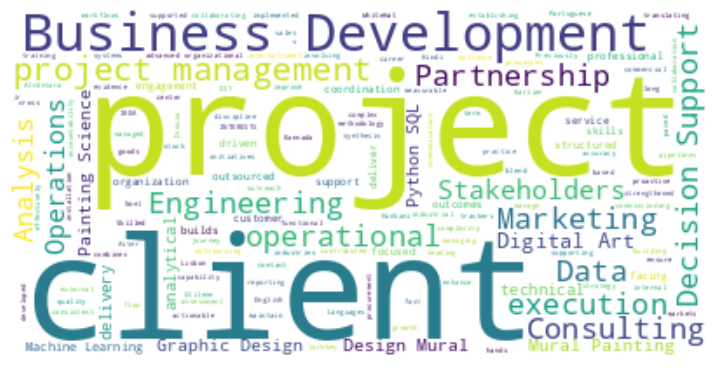

In [4]:
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure(figsize=(9,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### 5. Customised word cloud
We set the size, font limits, a colour map and the number of words, then **save** the image.
`collocations=True` keeps natural pairs together (e.g. *project management*, *machine learning*).

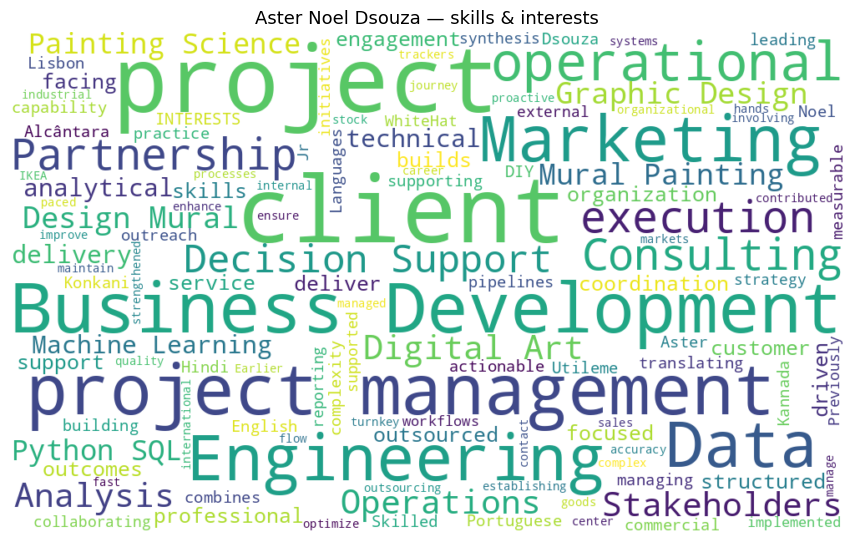

saved wordcloud_aster.png


In [5]:
wordcloud = WordCloud(
    stopwords=stopwords,
    width=1000, height=600,
    background_color="white",
    colormap="viridis",      # try "plasma", "cividis", "Dark2"
    max_words=120,
    max_font_size=110,
    collocations=True,
    random_state=42,
).generate(text)

plt.figure(figsize=(11,6.5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Aster Noel Dsouza — skills & interests", fontsize=13)
plt.show()

wordcloud.to_file("wordcloud_aster.png")
print("saved wordcloud_aster.png")

### 6. (Optional) Word cloud inside a shape
The exercise also lets you fit the words inside a shape. Here we use a simple **circle mask** made with
NumPy, so it works without uploading any image. To use a custom silhouette instead, upload a PNG with a
**white background and a solid black shape**, then:
```python
from PIL import Image
mask = np.array(Image.open("my_shape.png"))
```
and pass `mask=mask` to `WordCloud(...)`.

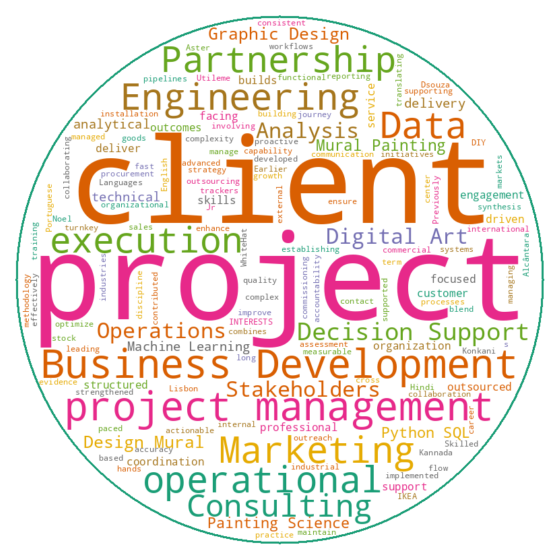

saved wordcloud_aster_shape.png


In [6]:
# build a circular mask (255 = background to avoid, 0 = area to fill)
h = w = 800
yy, xx = np.ogrid[:h, :w]
circle = (xx - w/2)**2 + (yy - h/2)**2 > (w/2 - 10)**2
mask = np.where(circle, 255, 0).astype("uint8")

wc_shape = WordCloud(
    stopwords=stopwords, mask=mask, background_color="white",
    contour_width=2, contour_color="#1b9e77", colormap="Dark2",
    max_words=150, random_state=42,
).generate(text)

plt.figure(figsize=(7,7))
plt.imshow(wc_shape, interpolation="bilinear")
plt.axis("off")
plt.show()
wc_shape.to_file("wordcloud_aster_shape.png")
print("saved wordcloud_aster_shape.png")

### 7. Short note
The cloud highlights my profile: **business development, project management, data analysis, Python and
SQL**, alongside consulting, marketing, engineering and operations, plus personal interests in **digital
art, graphic design and mural painting**. Stopwords were tuned so that generic application-letter wording
(e.g. *experience*, *opportunity*) does not dominate.

---
### AI-usage declaration
The notebook structure was adapted from the course Exercise 1 example. An AI assistant helped clean the
CV/cover-letter text into a punctuation-free keyword string and tune the stopword list; the wording,
keyword choices and final settings are my own.